# Qué tan firme es esto

Los precios son un supuesto y el competidor es una simulación. Esta sección mide cuánto de la conclusión depende de cada cosa.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd

from src import benchmark, brechas, data_io, robustez, viz
from src import config as cfg

pd.set_option("display.width", 200)
viz.aplicar_estilo()

panel = data_io.construir_panel()
plaza = data_io.panel_plaza(panel)
bench = benchmark.generar(plaza)

ventana = brechas.ventana(bench, 12)
material = brechas.filtrar_material(ventana)
d = brechas.descomponer(material)

res_mens = brechas.residuos_mensuales(bench, 24)
persist = brechas.persistencia(res_mens)
elast = brechas.elasticidad_promo(panel)
r = brechas.ranking(d, persist, elast)
prioritarias = r[r.prioritaria].sort_values("oport_contribucion", ascending=False)

prioritarias = r[r.prioritaria].sort_values("oport_contribucion", ascending=False)

## Si los precios estuvieran mal

Cada familia recibe un error de precio independiente de hasta 30 %, cuatrocientas veces, y se observa cuánto se mueve el total y el orden.

In [2]:
#| label: tbl-sensibilidad
#| tbl-cap: "Posición en el ranking bajo precios inciertos."
sens = robustez.sensibilidad_precios(prioritarias)
print(f"Total USD {sens.attrs['total_base']/1e3:,.0f} k  "
      f"(p10 {sens.attrs['total_p10']/1e3:,.0f} k · "
      f"p90 {sens.attrs['total_p90']/1e3:,.0f} k)")
sens.round(2)

Total USD 606 k  (p10 490 k · p90 728 k)


,city,family,oport_contribucion,posicion_mediana,posicion_p10,posicion_p90
2,Ambato,CLEANING,167194.26,2.0,1.0,3.0
153,Quito,PERSONAL CARE,148255.12,2.0,1.0,4.0
71,Guayaquil,"LIQUOR,WINE,BEER",135714.55,3.0,1.0,4.0
26,Cuenca,DAIRY,127268.40,3.0,1.0,4.0
133,Quevedo,DELI,27738.62,5.0,5.0,5.0


## Dónde poner el corte

Como el competidor es simulado, se conoce cuáles ventajas son reales: se puede medir qué encuentra y qué inventa cada umbral.

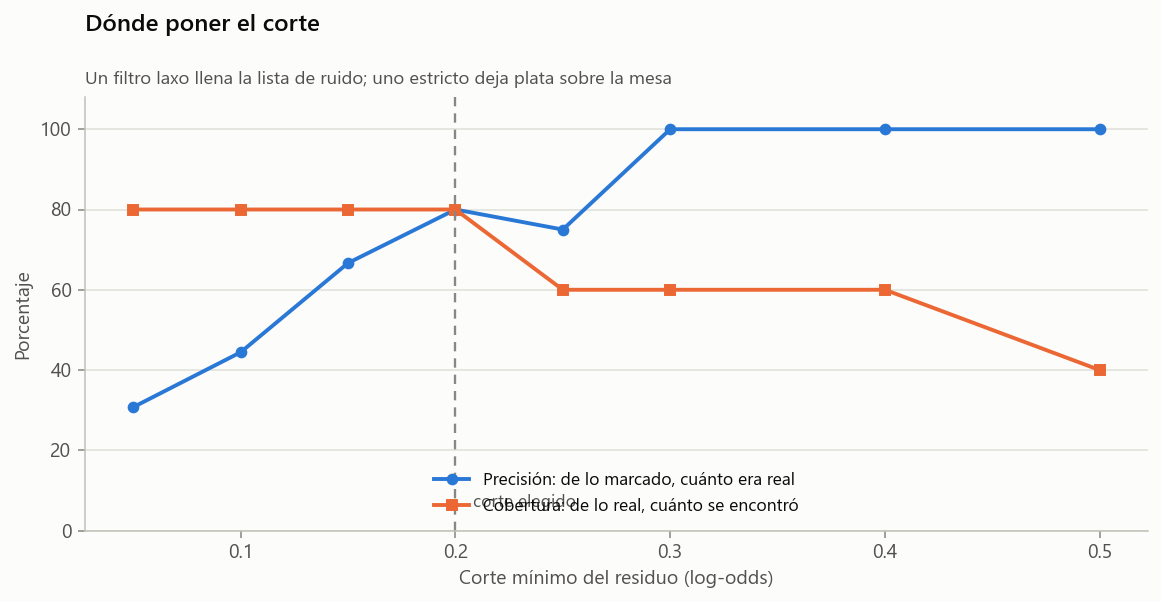

In [3]:
#| label: fig-umbral
#| fig-cap: "Precisión y cobertura del filtro según el corte."
fig = viz.fig_umbral(robustez.curva_umbral(d, persist, elast))

## Si se vuelve a sortear el mercado

Quince realizaciones del competidor con las mismas ventajas sembradas y distinto ruido.

Precisión media 0.62 · cobertura media 0.61


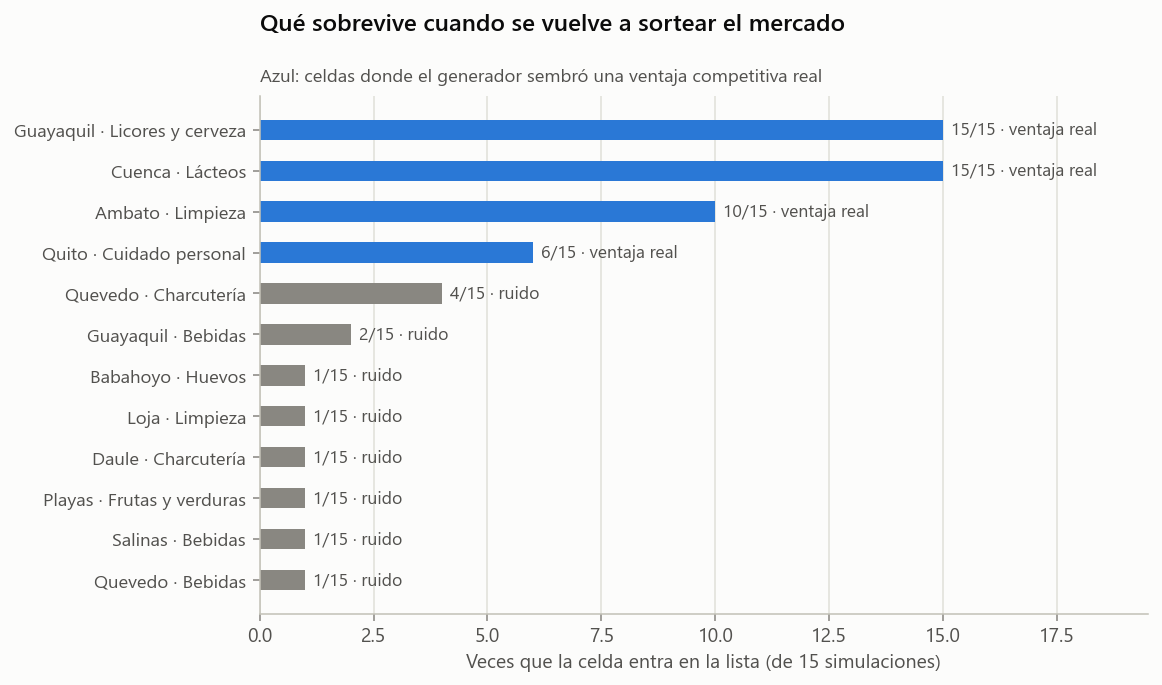

In [4]:
#| label: fig-semillas
#| fig-cap: "Frecuencia con que cada celda entra en la lista."
est = robustez.estabilidad_semillas(plaza, panel, semillas=15)
print(f"Precisión media {est.precision.mean():.2f} · "
      f"cobertura media {est.cobertura.mean():.2f}")
fig = viz.fig_semillas(est.attrs["frecuencia"], 15)